# Summary Statistics

This notebook starts by loading the `MALL_extended_5min.csv` dataset, displaying the dataframe, and printing a few basic diagnostics that will be useful for the summary statistics and thesis figures.

## 1. Loading in Data
Loading in the data from the `MALL_extended_5min.csv` dataset and running quick diagnostic checks. 

In [94]:
from pathlib import Path

import pandas as pd
from IPython.display import display

data_path = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_extended_5min.csv")
df = pd.read_csv(data_path, parse_dates=["Date"])

missing_values = df.isna().sum()
missing_columns = missing_values[missing_values > 0]

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Start date: {df['Date'].min().date()}")
print(f"End date: {df['Date'].max().date()}")
print(f"Total missing values: {int(missing_values.sum())}")

if missing_columns.empty:
    print("Columns with missing values: None")
else:
    print("Columns with missing values:")
    print(missing_columns.to_string())

display(df)

Dataset shape: 5489 rows x 40 columns
Start date: 1999-01-05
End date: 2020-08-06
Total missing values: 0
Columns with missing values: None


,Date,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,...,EURIBOR_3M,EURIBOR_3M_diff,EURO_10Y_SWAP,EURO_10Y_SWAP_diff,EURO_3M_OVERNIGHT_INDEX,EURO_3M_OVERNIGHT_INDEX_diff,EURIBOR_OIS_CS,TERM_CS,RV_target,logRV_target
0,1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,...,3.222,-0.012,4.1600,-0.0050,3.115,0.035,0.107,0.9380,0.000047,-9.966398
1,1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,...,3.214,-0.008,4.1620,0.0020,3.100,-0.015,0.114,0.9480,0.000237,-8.347779
2,1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,...,3.206,-0.008,4.1600,-0.0020,3.090,-0.010,0.116,0.9540,0.000168,-8.689606
3,1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,...,3.196,-0.010,4.1300,-0.0300,3.095,0.005,0.101,0.9340,0.000282,-8.175339
4,1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,...,3.193,-0.003,4.2250,0.0950,3.090,-0.005,0.103,1.0320,0.000191,-8.565468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5484,2020-07-31,0.000143,0.000098,0.000092,-8.854993,-9.228813,-9.292167,0.000068,0.000074,-0.009839,...,-0.463,-0.002,-0.2321,0.0179,-0.470,0.025,0.007,0.2309,0.000119,-9.032322
5485,2020-08-03,0.000119,0.000108,0.000091,-9.032322,-9.135653,-9.307138,0.000079,0.000041,0.000000,...,-0.469,-0.006,-0.2300,0.0021,-0.470,0.000,0.001,0.2390,0.000147,-8.823935
5486,2020-08-04,0.000147,0.000123,0.000094,-8.823935,-9.003406,-9.274082,0.000057,0.000090,-0.005685,...,-0.472,-0.003,-0.2651,-0.0351,-0.470,0.000,-0.002,0.2069,0.000066,-9.629448
5487,2020-08-05,0.000066,0.000130,0.000093,-9.629448,-8.949919,-9.280217,0.000032,0.000033,-0.002504,...,-0.467,0.005,-0.2251,0.0400,-0.470,0.000,0.003,0.2419,0.000148,-8.815894


## 2. Summary Statistics Table for the Final MALL Feature Set

This subsection reports the summary statistics for the final version of the MALL feature set used in the modelling exercise. The variables included in the table are `RVD`, `RVW`, `RVM`, `RVD_pos`, `RVD_neg`, `RD_neg`, `RW_neg`, `RM_neg`, `RQ`, `VSTOXX`, `CISS`, `logEPU_1m_lag`, `EURUSD_ret`, `BRENT_ret`, `NIKKEI_ret`, `NIKKEI_sq`, `SP500_ret_lag`, `SP500_sq_lag`, `M1W`, `M1M`, `EURIBOR_OIS_CS`, and `TERM_CS`.

In [97]:
import numpy as np

MALL = df.sort_values("Date").set_index("Date").copy()

summary_cols = [
    "RVD", "RVW", "RVM",
    "RVD_pos", "RVD_neg",
    "RD_neg", "RW_neg", "RM_neg",
    "RQ",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M",
    "EURIBOR_OIS_CS", "TERM_CS"
]

MALL_display = pd.DataFrame({
    "RVD": np.sqrt(MALL["RVD"] * 252) * 100,
    "RVW": np.sqrt(MALL["RVW"] * 252) * 100,
    "RVM": np.sqrt(MALL["RVM"] * 252) * 100,
    "RVD_pos": np.sqrt(MALL["RVD_pos"] * 252) * 100,
    "RVD_neg": np.sqrt(MALL["RVD_neg"] * 252) * 100,
    "RD_neg": MALL["RD_neg"] * 100,
    "RW_neg": MALL["RW_neg"] * 100,
    "RM_neg": MALL["RM_neg"] * 100,
    "RQ": MALL["RQ"] * 1e6,
    "VSTOXX": MALL["VSTOXX"],
    "CISS": MALL["CISS"],
    "logEPU_1m_lag": MALL["logEPU_1m_lag"],
    "EURUSD_ret": MALL["EURUSD_ret"] * 100,
    "BRENT_ret": MALL["BRENT_ret"] * 100,
    "NIKKEI_ret": MALL["NIKKEI_ret"] * 100,
    "NIKKEI_sq": MALL["NIKKEI_sq"] * 1e4,
    "SP500_ret_lag": MALL["SP500_ret_lag"] * 100,
    "SP500_sq_lag": MALL["SP500_sq_lag"] * 1e4,
    "M1W": MALL["M1W"] * 100,
    "M1M": MALL["M1M"] * 100,
    "EURIBOR_OIS_CS": MALL["EURIBOR_OIS_CS"],
    "TERM_CS": MALL["TERM_CS"],
})

summary_table = pd.DataFrame({
    "Mean": MALL_display[summary_cols].mean(),
    "Std. Dev.": MALL_display[summary_cols].std(),
    "Skew.": MALL_display[summary_cols].skew(),
    "Exc. Kurt.": MALL_display[summary_cols].kurt(),
    "Min": MALL_display[summary_cols].min(),
    "Median": MALL_display[summary_cols].median(),
    "Max": MALL_display[summary_cols].max(),
}).round(2)

start_date = MALL.index.min().strftime("%Y-%m-%d")
end_date = MALL.index.max().strftime("%Y-%m-%d")

styled_summary = (
    summary_table.style
    .set_caption(
        "Table: Summary Statistics of MHAR Extension Variables and Final MALL Predictors -- EURO STOXX 50 "
        f"({start_date} to {end_date}). "
        "RVD, RVW, RVM, RVD_pos, and RVD_neg are shown as annualized std (%). "
        "RD_neg, RW_neg, RM_neg, EURUSD_ret, BRENT_ret, NIKKEI_ret, SP500_ret_lag, M1W, and M1M are shown as %. "
        "RQ is scaled by 10^6, while NIKKEI_sq and SP500_sq_lag are scaled by 10^4. "
        "All remaining variables are shown in their original units."
    )
    .format(lambda x: f"{x:,.2f}")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px"), ("color", "black"), ("caption-side", "top")]},
        {"selector": "thead tr th", "props": [("background-color", "white"), ("color", "black"), ("font-size", "11px"), ("text-align", "center"), ("padding", "6px 10px"), ("border-top", "2px solid black"), ("border-bottom", "1px solid black"), ("font-weight", "bold")]},
        {"selector": "tbody tr th", "props": [("font-size", "11px"), ("font-weight", "bold"), ("text-align", "left"), ("padding", "4px 10px"), ("color", "black"), ("background-color", "white"), ("border-right", "1px solid black")]},
        {"selector": "tbody tr td", "props": [("font-size", "11px"), ("text-align", "right"), ("padding", "4px 10px"), ("background-color", "white"), ("color", "black")]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th", "props": [("border-bottom", "2px solid black")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%"), ("border-top", "2px solid black"), ("border-bottom", "2px solid black")]},
        {"selector": "td, th", "props": [("border-left", "none"), ("border-right", "none")]},
    ])
)

display(styled_summary)

,Mean,Std. Dev.,Skew.,Exc. Kurt.,Min,Median,Max
RVD,16.14,9.96,3.17,20.33,0.15,13.76,157.11
RVW,16.51,9.33,2.62,11.04,4.52,14.18,93.58
RVM,16.83,8.75,2.15,6.46,5.29,14.40,71.78
RVD_pos,11.22,6.79,2.77,13.51,0.09,9.54,83.33
RVD_neg,11.37,7.66,3.80,32.94,0.12,9.50,138.64
RD_neg,-0.44,0.80,-3.37,18.27,-10.54,0.00,0.00
RW_neg,-0.21,0.38,-3.83,25.44,-5.41,0.00,0.00
RM_neg,-0.10,0.19,-3.51,17.55,-1.91,0.00,0.00
RQ,0.65,19.50,50.39,"2,681.48",0.00,0.01,"1,129.75"
VSTOXX,23.91,9.78,1.71,4.18,10.68,21.98,87.51


## 3. Indexed Macro-Financial Panel for the Final MALL Feature Set

This subsection plots the indexed time-series paths for `VSTOXX`, `EURUSD`, `BRENT`, `EPU`, `CISS`, `NIKKEI`, `SP500`, `EURIBOR_OIS_CS`, and `TERM_CS`, where all series are rebased to 100 on `1999-01-05`. In the plotted panel, `EURIBOR_OIS_CS` is labelled `ON SPREAD` and `TERM_CS` is labelled `TERM SPREAD`, and the shaded bands mark the main crisis periods used elsewhere in the thesis.

Figure saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data/MacroPanel_final_MALL.pdf


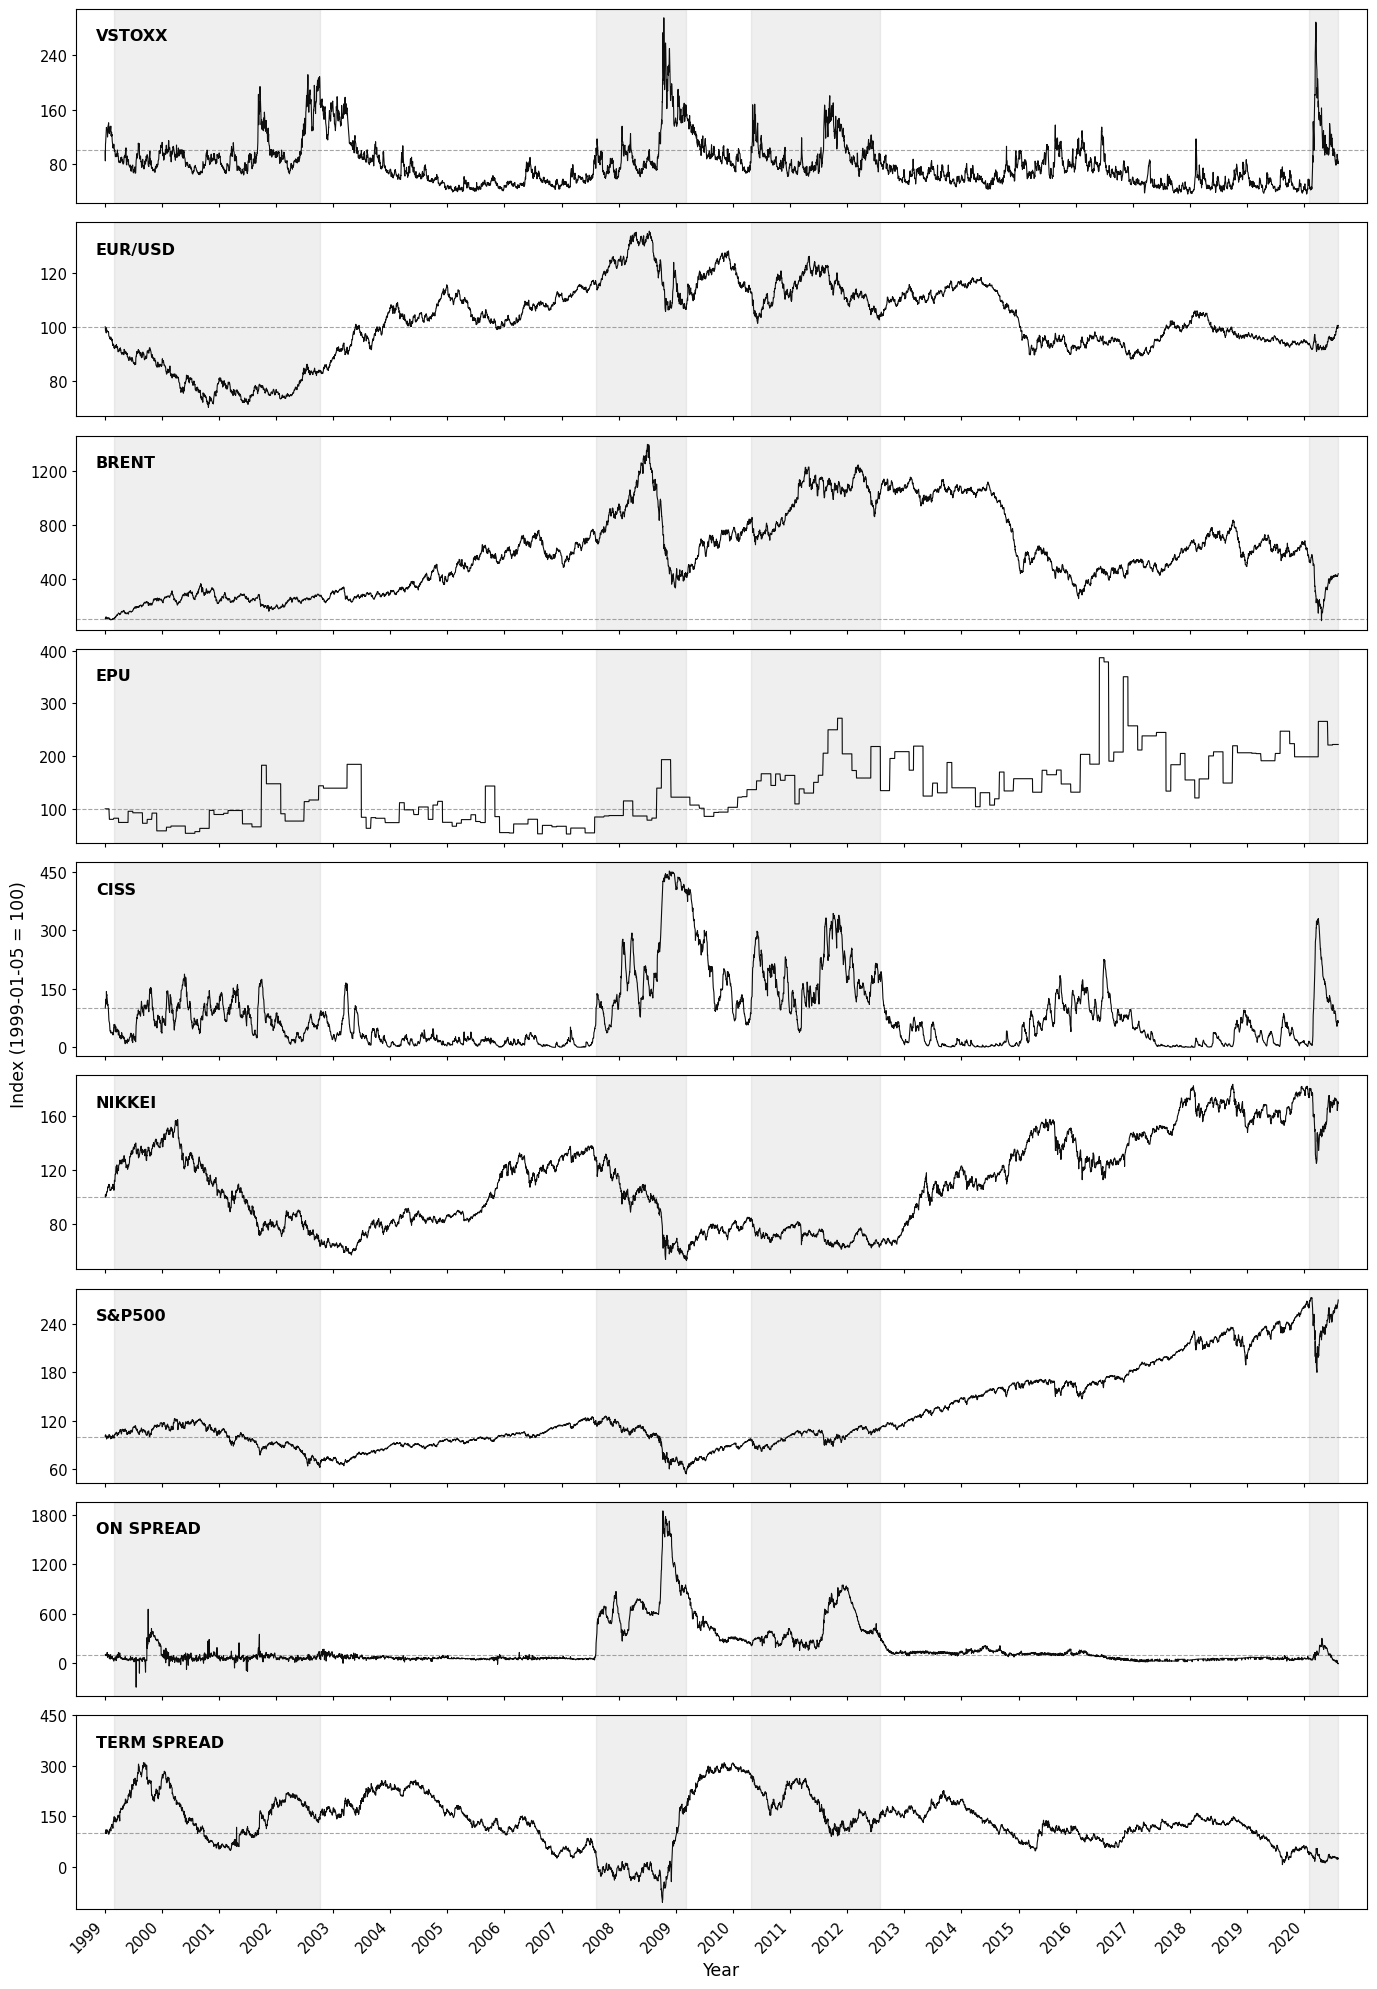

In [100]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

nikkei_path = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/NIKKEI225.csv")
sp500_path = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/S&P500.csv")
figure_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data")
figure_dir.mkdir(parents=True, exist_ok=True)

NIKKEI = pd.read_csv(nikkei_path)
NIKKEI["observation_date"] = pd.to_datetime(NIKKEI["observation_date"])
NIKKEI = NIKKEI.set_index("observation_date").sort_index()
NIKKEI.index.name = "Date"
NIKKEI["NIKKEI225"] = NIKKEI["NIKKEI225"].ffill()

SP500 = pd.read_csv(sp500_path)
SP500.columns = SP500.columns.str.strip()
SP500 = SP500[["Date", "Close"]].copy()
SP500["Date"] = pd.to_datetime(SP500["Date"], format="%m/%d/%y")
SP500 = SP500.set_index("Date").sort_index()

macro_panel = pd.DataFrame({
    "VSTOXX": MALL["VSTOXX"],
    "EURUSD": MALL["EURUSD"],
    "BRENT": MALL["BRENT"],
    "EPU": MALL["EPU"],
    "CISS": MALL["CISS"],
    "NIKKEI": NIKKEI["NIKKEI225"].reindex(MALL.index).ffill(),
    "SP500": SP500["Close"].reindex(MALL.index).ffill(),
    "ON_SPREAD": MALL["EURIBOR_OIS_CS"],
    "TERM_SPREAD": MALL["TERM_CS"],
})

macro_panel.index = pd.to_datetime(macro_panel.index)
macro_panel = macro_panel.sort_index().dropna()
df_indexed = macro_panel.div(macro_panel.iloc[0]).mul(100)

crisis_periods = [
    ("1999-03-01", "2002-10-09"),
    ("2007-08-09", "2009-03-09"),
    ("2010-04-27", "2012-07-26"),
    ("2020-02-01", "2020-08-07"),
]

series_names = ["VSTOXX", "EURUSD", "BRENT", "EPU", "CISS", "NIKKEI", "SP500", "ON_SPREAD", "TERM_SPREAD"]
panel_labels = ["VSTOXX", "EUR/USD", "BRENT", "EPU", "CISS", "NIKKEI", "S&P500", "ON SPREAD", "TERM SPREAD"]

start_data = df_indexed.index.min()
end_data = df_indexed.index.max()
padding = pd.DateOffset(months=6)

fig, axes = plt.subplots(
    9, 1,
    figsize=(14, 20),
    sharex=True
)

for ax, col, label in zip(axes, series_names, panel_labels):
    ax.plot(
        df_indexed.index,
        df_indexed[col],
        color="black",
        linewidth=0.8,
        alpha=0.95,
        zorder=3
    )

    ax.axhline(
        100,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7,
        zorder=1
    )

    for start, end in crisis_periods:
        ax.axvspan(
            pd.Timestamp(start),
            pd.Timestamp(end),
            color="gray",
            alpha=0.12,
            zorder=0
        )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")

    ax.text(
        0.015, 0.90, label,
        transform=ax.transAxes,
        fontsize=11.5,
        fontweight="bold",
        ha="left",
        va="top"
    )

    ax.tick_params(axis="y", labelsize=10.5, length=3, width=0.8)
    ax.tick_params(axis="x", labelsize=10.5, length=3, width=0.8)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    if col == "TERM_SPREAD":
        ax.set_ylim(top=450)
    ax.grid(False)
    ax.set_xlim(start_data - padding, end_data + padding)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xticks(pd.date_range("1999-01-01", "2020-01-01", freq="YS"))

plt.setp(
    axes[-1].get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10.5
)

for ax in axes[:-1]:
    ax.tick_params(axis="x", labelbottom=False)

fig.supylabel("Index (1999-01-05 = 100)", fontsize=12.5, x=0.02)
axes[-1].set_xlabel("Year", fontsize=12.5)

plt.tight_layout()
fig.subplots_adjust(hspace=0.10)

figure_path = figure_dir / "MacroPanel_final_MALL.pdf"
plt.savefig(figure_path, format="pdf", bbox_inches="tight")
print(f"Figure saved to: {figure_path}")
plt.show()


## 4. Annualized Realized Volatility over the Full Sample

This subsection plots the annualized realized volatility based on `RVD` over the full sample period. The figure marks the main crisis windows used in the thesis and saves the output in the standard project figure directory under the original filename `RV_time_series_5min.pdf`.

Figure saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data/RV_time_series_5min.pdf


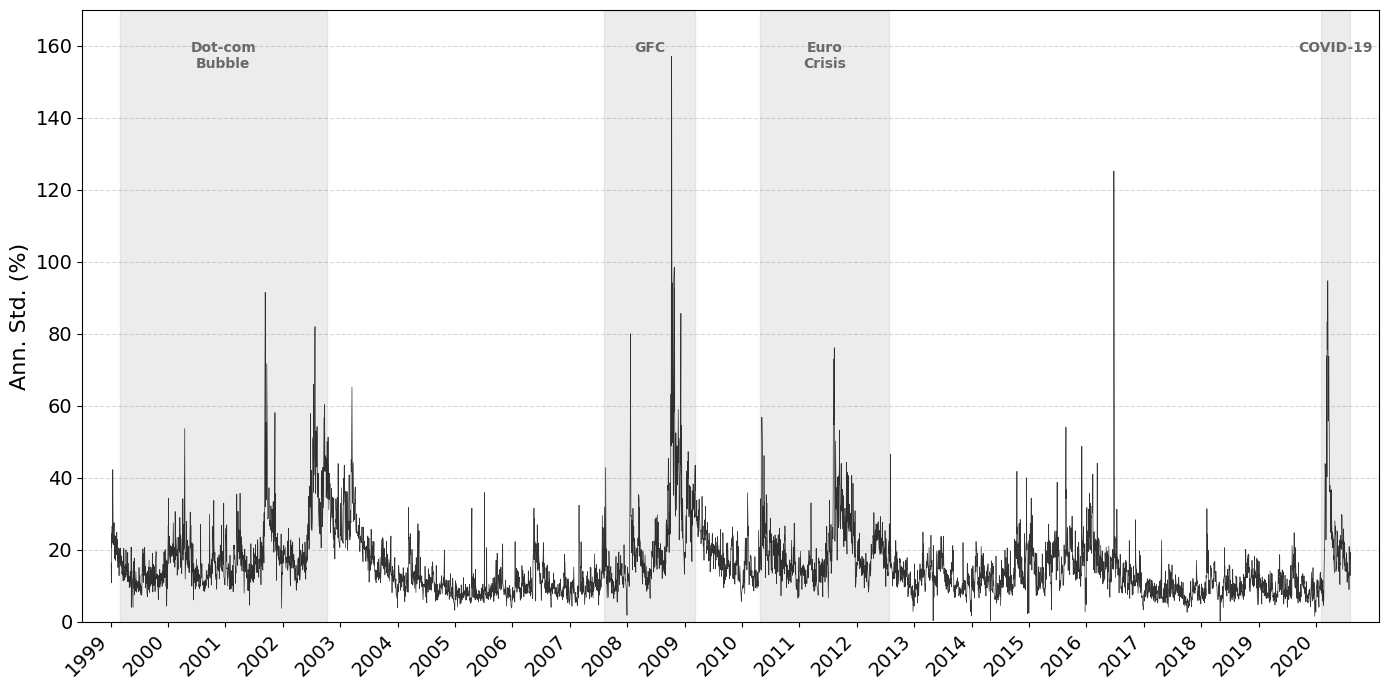

In [103]:
import os

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

MALL = df.sort_values("Date").set_index("Date").copy()

# Optional figure export directory for the 5-minute project
figure_dir = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data"
os.makedirs(figure_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 7))
rv_ann = np.sqrt(MALL["RVD"] * 252) * 100

ax.plot(MALL.index, rv_ann, color="black", linewidth=0.5, alpha=0.8)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)
ax.set_ylim(0, 170)

start_data = MALL.index.min()
end_data = MALL.index.max()
padding = pd.DateOffset(months=6)
ax.set_xlim(start_data - padding, end_data + padding)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

valid_ticks = [
    t for t in ax.get_xticks()
    if mdates.date2num(pd.Timestamp(f"{start_data.year}-01-01")) <= t
    <= mdates.date2num(pd.Timestamp(f"{end_data.year}-12-31"))
]
ax.set_xticks(valid_ticks)
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)

crisis_periods = [
    ("1999-03-01", "2002-10-09", "Dot-com\nBubble"),
    ("2007-08-09", "2009-03-09", "GFC"),
    ("2010-04-27", "2012-07-26", "Euro\nCrisis"),
    ("2020-02-01", "2020-08-07", "COVID-19"),
]

for start, end, label in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color="gray")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.95, label, fontsize=10, ha="center", va="top", color="dimgray", fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
figure_path = os.path.join(figure_dir, "RV_time_series_5min.pdf")
plt.savefig(figure_path, format="pdf", bbox_inches="tight")
print(f"Figure saved to: {figure_path}")
plt.show()


## 5. Annualized Realized Volatility Boxplots by Year

This subsection plots yearly boxplots of annualized realized volatility based on `RVD` across the full sample. The figure also marks the yearly maximum volatility observation in each year and annotates the corresponding calendar date, and it is saved under the original filename `RV_box_plot_5min.pdf`.

Figure saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data/RV_box_plot_5min.pdf


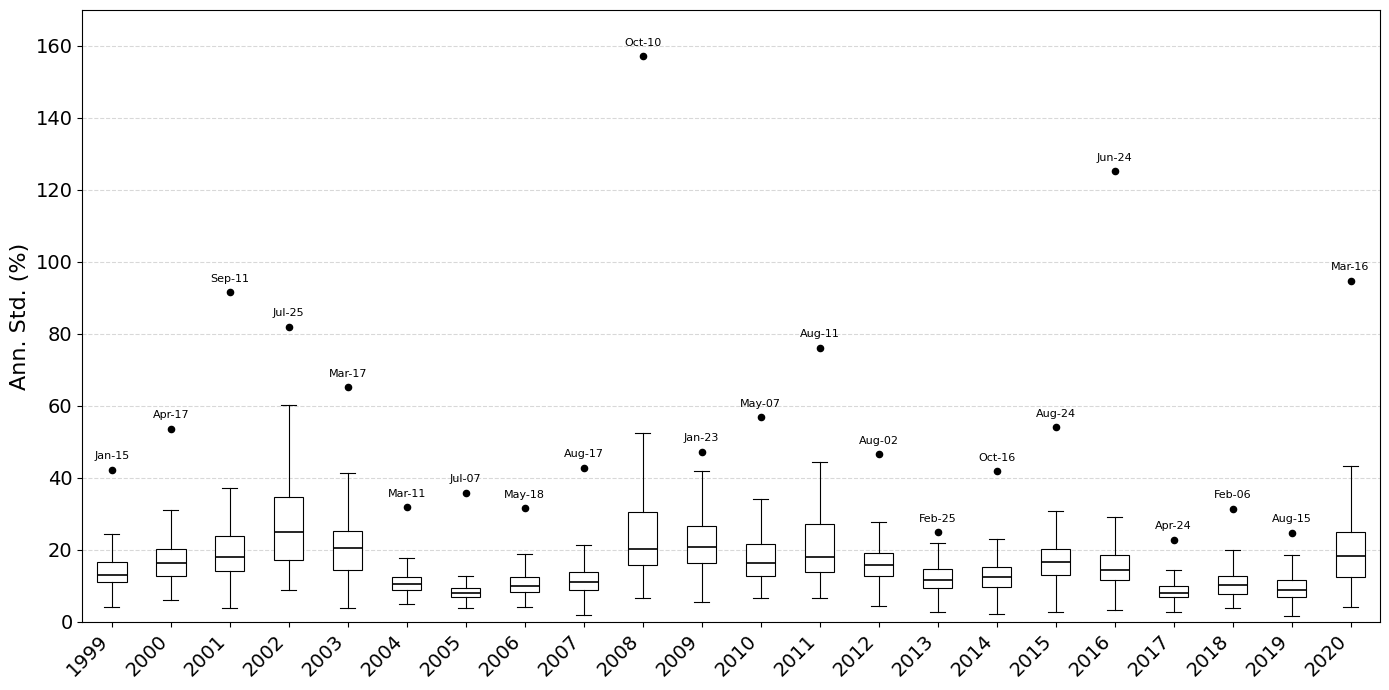

In [106]:
import os

import matplotlib.pyplot as plt
import numpy as np

MALL = df.sort_values("Date").set_index("Date").copy()

figure_dir = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data"
os.makedirs(figure_dir, exist_ok=True)

rv_ann = np.sqrt(MALL["RVD"] * 252) * 100
rv_ann_df = pd.DataFrame({
    "RVD_ann": rv_ann,
    "Year": MALL.index.year,
    "Date": MALL.index,
})

years = sorted(rv_ann_df["Year"].unique())
data_by_year = [rv_ann_df[rv_ann_df["Year"] == y]["RVD_ann"].values for y in years]

yearly_max_idx = rv_ann_df.groupby("Year")["RVD_ann"].idxmax()
yearly_max_val = rv_ann_df.loc[yearly_max_idx, "RVD_ann"]
yearly_max_date = rv_ann_df.loc[yearly_max_idx, "Date"]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(
    data_by_year,
    positions=range(len(years)),
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="white", color="black", linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)

y_range = rv_ann_df["RVD_ann"].max() - rv_ann_df["RVD_ann"].min()
fixed_offset = y_range * 0.015

for i, year in enumerate(years):
    max_val = yearly_max_val[yearly_max_val.index == yearly_max_idx[year]].values[0]
    max_date = yearly_max_date[yearly_max_date.index == yearly_max_idx[year]].values[0]
    max_date_str = pd.Timestamp(max_date).strftime("%b-%d")
    ax.scatter(i, max_val, color="black", s=20, zorder=5, marker="o")
    ax.text(i, max_val + fixed_offset, max_date_str, fontsize=8, ha="center", va="bottom", color="black")

ax.set_ylim(0, 170)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)
plt.yticks(fontsize=14)
ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
figure_path = os.path.join(figure_dir, "RV_box_plot_5min.pdf")
plt.savefig(figure_path, format="pdf", bbox_inches="tight")
print(f"Figure saved to: {figure_path}")
plt.show()
